In [ ]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "flexi_ct").is_dir() and (candidate / "demo_utils").is_dir():
            return candidate
    raise RuntimeError("Could not find the Flexi_CT repository root from the current notebook directory.")


def input_path_from_env(env_var: str, default_relative_path: str) -> Path:
    configured = os.environ.get(env_var)
    if configured:
        return Path(configured).expanduser()
    return REPO_ROOT / default_relative_path


def required_input_path(env_var: str, default_relative_path: str, label: str) -> Path:
    path = input_path_from_env(env_var, default_relative_path)
    if not path.exists():
        raise FileNotFoundError(
            f"{label} not found at {path}. Place it there or set the {env_var} environment variable."
        )
    return path


def optional_input_path(env_var: str, default_relative_path: str, label: str) -> Path | None:
    path = input_path_from_env(env_var, default_relative_path)
    if path.exists():
        return path
    if os.environ.get(env_var):
        raise FileNotFoundError(f"{label} configured by {env_var} was not found at {path}.")
    return None


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
repo_root_text = str(REPO_ROOT)
if repo_root_text not in sys.path:
    sys.path.insert(0, repo_root_text)

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise RuntimeError("ipywidgets is required for the interactive controls in this notebook.") from exc

from demo_utils.preprocessing import (
    WINDOWS,
    center_pad_to_square,
    resize_slice,
    resample_mask_to_reference,
    resample_sitk_image,
    window_ct_slice,
    zscore_clipped_volume,
)
from demo_utils.similarity import click_xy_to_patch_index

plt.rcParams["figure.dpi"] = 110
try:
    from skimage.filters import threshold_otsu
    from skimage.morphology import remove_small_objects, remove_small_holes, binary_closing, disk
    from skimage.segmentation import clear_border
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False
from sklearn.decomposition import PCA


In [ ]:
from flexi_ct.models import flexi_ct_backbone_base
import os

os.environ["FLEXICT_2D_CHECKPOINT"] = "PATH_TO_2D_CHECKPOINT"

model = flexi_ct_backbone_base(
    in_chans=1,
    patch_size=8,
    drop_path_rate=0.2,
    layerscale_init=1.0e-05,
    n_storage_tokens=4,
    qkv_bias=False,
    mask_k_bias=True,
)

default_device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(os.environ.get("FLEXICT_DEVICE", default_device))

checkpoint_path = required_input_path(
    "FLEXICT_2D_CHECKPOINT",
    "assets/2D_final_model.pth",
    "2D Flexi_CT checkpoint",
)

chkpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
state_dict = {
    k[len("backbone."):]: v
    for k, v in chkpt["teacher"].items()
    if k.startswith("backbone.") and "ibot" not in k and "dino_head" not in k
}

missing, unexpected = model.load_state_dict(state_dict, strict=True)
model.to(device)
model.eval()


Flexi_CT_Backbone(
  (patch_embed_2D): PatchEmbedND(
    (proj): Conv2d(1, 864, kernel_size=(8, 8), stride=(8, 8))
    (norm): Identity()
  )
  (patch_embed_3D): PatchEmbedND(
    (proj): Conv3d(1, 864, kernel_size=(8, 8, 8), stride=(8, 8, 8))
    (norm): Identity()
  )
  (rope_embed_2D): RopePositionEmbedding()
  (rope_embed_3D): RopePositionEmbedding3D()
  (blocks): ModuleList(
    (0-15): 16 x SelfAttentionBlock(
      (norm1): LayerNorm((864,), eps=1e-06, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=864, out_features=2592, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=864, out_features=864, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((864,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=864, out_features=3456, bias=True)
        (act): GELU(approximate='none')


In [4]:
def visualize_pca(sample, model, input_size):
    print(sample.shape)
    norm_sample = (sample - torch.min(sample)) / (torch.max(sample)- torch.min(sample))
    print(torch.min(sample), torch.max(sample))

    with torch.no_grad():
        features = model(sample.unsqueeze(0).to(device), is_training=True)['x_norm_patchtokens']

    pca = PCA(n_components=3, whiten=True)
    pca_features = pca.fit_transform(features.squeeze(0).cpu().detach().numpy()) # [input_size*input_size, 3]

    # put pca features into 0-1 scale
    norm_pca_feats = (pca_features - pca_features.min()) / (pca_features.max() - pca_features.min())
    norm_pca_feats = norm_pca_feats.reshape(input_size//model.patch_size, input_size//model.patch_size, -1)

    # Create one figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # (rows=1, cols=2), adjust figsize for bigger plot

    # First subplot: CT image
    axes[0].imshow(np.transpose(norm_sample.numpy(), (1,2,0)), cmap="gray")
    axes[0].axis('off')
    axes[0].set_title("CT image")

    # Second subplot: PCA features
    axes[1].imshow(norm_pca_feats)
    axes[1].axis('off')
    axes[1].set_title("PCA Features")

    plt.tight_layout()
    plt.show()

def visualize_cls_patch(sample, model, input_size):
    norm_sample = (sample - torch.min(sample)) / (torch.max(sample)- torch.min(sample))
    print(torch.min(sample), torch.max(sample))
    num_patches_per_side = input_size // model.patch_size
    with torch.no_grad():
        outputs = model(sample.unsqueeze(0).to(device), is_training=True)
        cls_token = outputs['x_norm_clstoken']
        patch_token = outputs['x_norm_patchtokens']

        patch_token = torch.nn.functional.normalize(patch_token, dim=-1) 
        cls_token = torch.nn.functional.normalize(cls_token, dim=-1) 

        # Compute cosine similarity between CLS token and each patch token
        # cls_token: (1, D), patch_token: (1, N_patches, D)
        similarity = torch.matmul(patch_token, cls_token.unsqueeze(-1))  # (1, N_patches, 1)
        print(similarity.shape)
        similarity = similarity.reshape(1, num_patches_per_side, num_patches_per_side, -1).permute(0, 3, 1, 2).contiguous()
        similarity = similarity.squeeze(-1).squeeze(0)  # (N_patches,)
        # Convert to numpy for visualization
        similarity_np = similarity.cpu().numpy()
        # Reshape similarity to 2D grid
        similarity_map = similarity_np[0]

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # (rows=1, cols=2), adjust figsize for bigger plot
    # First subplot: CT image
    axes[0].imshow(np.transpose(norm_sample.numpy(), (1,2,0)), cmap="gray")
    axes[0].axis('off')
    axes[0].set_title("CT image")

    # Second subplot: PCA features
    axes[1].imshow(similarity_map, cmap="viridis", vmin=-1, vmax=1)
    axes[1].axis('off')
    axes[1].set_title("CLS vs Patch Similarity Map")

    plt.tight_layout()
    plt.show()

    # Print some statistics
    print(f"Similarity range: {similarity_np.min():.3f} to {similarity_np.max():.3f}")
    print(f"Mean similarity: {similarity_np.mean():.3f}")

def visualize_ref_patch(sample, model, input_size, location = 'center'):
    patch_size = model.patch_size
    num_patches_per_side = input_size // patch_size
    center_row = num_patches_per_side // 2
    center_col = num_patches_per_side // 2
    if location == 'center':
        center_patch_idx = center_row * num_patches_per_side + center_col
    else:
        center_patch_idx = location
        center_row = center_patch_idx // num_patches_per_side
        center_col = center_patch_idx % num_patches_per_side

    norm_sample = (sample - torch.min(sample)) / (torch.max(sample)- torch.min(sample))
    print(torch.min(sample), torch.max(sample))

    with torch.no_grad():
        outputs = model(sample.unsqueeze(0).to(device), is_training=True)
        patch_token = outputs['x_norm_patchtokens']
        patch_token = torch.nn.functional.normalize(patch_token, dim=-1) 
        patch_token = patch_token.squeeze(0)
        reference_token = patch_token[center_patch_idx:center_patch_idx+1]
        similarity = torch.matmul(patch_token, reference_token.T)  # (N_patches, 1)
        similarity = similarity.squeeze(-1)  # (N_patches,)
        similarity = similarity.reshape(1, num_patches_per_side, num_patches_per_side, -1).permute(0, 3, 1, 2).contiguous()
        similarity = similarity.squeeze(-1).squeeze(0)  # (N_patches,)
        # Convert to numpy for visualization
        similarity = (similarity - torch.min(similarity)) / (torch.max(similarity)- torch.min(similarity))
        similarity_np = similarity.cpu().numpy()
        
        # Reshape similarity to 2D grid
        similarity_map = similarity_np[0]

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # (rows=1, cols=2), adjust figsize for bigger plot
    # First subplot: CT image
    axes[0].imshow(np.transpose(norm_sample.numpy(), (1,2,0)), cmap="gray")
    axes[0].axis('off')
    axes[0].set_title("CT image")

    # Second subplot: PCA features
    # Mark the center patch with a red rectangle
    axes[1].imshow(similarity_map, cmap="viridis", vmin=-1, vmax=1)
    axes[1].plot(center_col, center_row, 'rs', markersize=8, markerfacecolor='red', 
                markeredgecolor='white', markeredgewidth=1)
    axes[1].axis('off')
    axes[1].set_title("Reference vs Patch Similarity Map")
    plt.tight_layout()
    plt.show()

    # Print some statistics
    print(f"Similarity range: {similarity_np.min():.3f} to {similarity_np.max():.3f}")
    print(f"Mean similarity: {similarity_np.mean():.3f}")

import torch.nn.functional as F

def mask_to_patchgrid(mask_hw: np.ndarray, patch_size: int) -> np.ndarray:
    """Downsample a pixel mask HxW -> (H/ps, W/ps) via max-pooling (any-positive -> True)."""
    H, W = mask_hw.shape
    assert H % patch_size == 0 and W % patch_size == 0, "Image size must be divisible by patch size."
    t = torch.from_numpy(mask_hw.astype(np.float32))[None, None]  # [1,1,H,W]
    g = F.max_pool2d(t, kernel_size=patch_size, stride=patch_size)  # [1,1,H/ps,W/ps]
    return (g[0, 0].numpy() > 0.5)

def visualize_pca_masked(sample: torch.Tensor, model, input_size: int,
                         subject_only_pca: bool = True,
                         do_background_subtract: bool = True,
                         pad: int = 8):
    """
    - Builds a robust subject (foreground) mask from the CT.
    - Maps that mask onto the patch grid.
    - Optionally subtracts the background mean vector from all patch tokens.
    - Fits PCA on subject-only tokens (if subject_only_pca=True), then projects all tokens.
    - Zeros out the background in the visualization.
    - Also shows a crop around the subject for convenience.
    """
    # 0) normalize a copy for visualization
    norm_sample = (sample - sample.min()) / (sample.max() - sample.min() + 1e-8)

    # 1) foreground mask on pixels
    fg_mask_px = make_foreground_mask(norm_sample)

    # 2) get patch tokens
    with torch.no_grad():
        outputs = model(sample.unsqueeze(0).to(device), is_training=True)
        patch_tokens = outputs['x_norm_patchtokens'].squeeze(0)  # [N_patches, D]
    D = patch_tokens.shape[-1]
    ps = model.patch_size
    n_side = input_size // ps
    assert patch_tokens.shape[0] == n_side * n_side

    # 3) downsample mask to patch grid
    fg_mask_pg = mask_to_patchgrid(fg_mask_px, patch_size=ps)            # (n_side, n_side)
    fg_mask_flat = torch.from_numpy(fg_mask_pg.reshape(-1)).bool().to(patch_tokens.device)  # [N_patches]

    # 4) background subtraction (optional)
    pt = patch_tokens
    if do_background_subtract:
        if (~fg_mask_flat).any():
            bg_mean = pt[~fg_mask_flat].mean(0, keepdim=True)  # [1,D]
        else:
            bg_mean = pt.mean(0, keepdim=True)
        pt = pt - bg_mean  # center wrt background

    # 5) PCA
    pt_np = pt.detach().cpu().numpy()                      # [N,D]
    if subject_only_pca and fg_mask_flat.any():
        pca = PCA(n_components=3, whiten=True)
        pca.fit(pt_np[fg_mask_flat.cpu().numpy()])
    else:
        pca = PCA(n_components=3, whiten=True)
        pca.fit(pt_np)
    pca_proj = pca.transform(pt_np)                        # [N,3]
    pca_proj = (pca_proj - pca_proj.min()) / (pca_proj.max() - pca_proj.min() + 1e-8)
    pca_map = pca_proj.reshape(n_side, n_side, 3)

    # 6) zero-out background in the visualization
    pca_map_masked = pca_map.copy()
    bg_idx = ~fg_mask_pg
    pca_map_masked[bg_idx] = 0.0

    # 7) make a quick crop for the CT visualization (purely for display)
    ct_hw = _to_hw_numpy(norm_sample)

    # 8) visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 8)) 
    axes[0].imshow(ct_hw, cmap='gray')
    axes[0].set_title("CT")
    axes[0].axis('off')

    axes[1].imshow(pca_map_masked)
    axes[1].set_title("PCA on foreground")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


def make_foreground_mask(
    sample: torch.Tensor,
    min_object_frac: float = 0.01,
    closing_radius: int = 3,
    use_otsu: bool = True,
    manual_thresh: float | None = None,
    # NEW:
    fill_internal_holes: bool = True,
    clear_border_first: bool = True,
) -> np.ndarray:
    """
    Returns a boolean HxW mask of the subject (largest cleaned component).
    For chest CT, set fill_internal_holes=True to avoid lung holes.
    """
    img = _to_hw_numpy((sample - sample.min()) / (sample.max() - sample.min() + 1e-8))
    h, w = img.shape

    # --- initial threshold ---
    if manual_thresh is not None:
        t = float(manual_thresh)
    elif _HAS_SKIMAGE and use_otsu:
        t = float(threshold_otsu(img))
        t = max(t, 0.03)  # safety floor
    else:
        t = float(np.quantile(img, 0.60))  # fallback
    raw = img > t

    # --- cleanup ---
    if _HAS_SKIMAGE:
        # (optional) remove components touching image border (table/coil, etc.)
        if clear_border_first:
            raw = clear_border(raw)

        # small smoothing/closure
        if closing_radius > 0:
            raw = binary_closing(raw, footprint=disk(closing_radius))

        # NEW: fill *all* interior holes so lungs don't appear as holes
        if fill_internal_holes:
            try:
                # Fast & robust if SciPy is available
                from scipy.ndimage import binary_fill_holes
                raw = binary_fill_holes(raw)
            except Exception:
                # Skimage fallback: set a huge area threshold to fill big cavities
                raw = remove_small_holes(raw, area_threshold=int(h * w))

        # keep some robustness for tiny gaps/speckles
        raw = remove_small_holes(raw, area_threshold=int(0.002 * h * w))
        raw = remove_small_objects(raw, min_size=max(64, int(min_object_frac * h * w)))
    else:
        # minimal path if skimage isn't installed
        pass

    # --- keep largest connected blob ---
    try:
        from skimage.measure import label
        lab = label(raw)
        if lab.max() > 0:
            sizes = np.bincount(lab.ravel())
            sizes[0] = 0
            keep_label = sizes.argmax()
            mask = lab == keep_label
        else:
            mask = raw
    except Exception:
        mask = raw

    return mask.astype(bool)
def _to_hw_numpy(img_chw: torch.Tensor) -> np.ndarray:
    if img_chw.ndim == 3:
        c, h, w = img_chw.shape
        if c == 1:
            img = img_chw[0]
        else:
            img = img_chw.mean(dim=0)
    elif img_chw.ndim == 2:
        img = img_chw
        h, w = img.shape
    else:
        raise ValueError(f"Unexpected sample shape: {img_chw.shape}")
    img = img.clamp(0, 1)  # ensure 0-1
    return img.numpy()

def visualize_ref_patch_masked(
    sample: torch.Tensor,
    model,
    input_size: int,
    location: str | int = "center",
    mask_out_value: float = 0.0,
    use_alpha: bool = True,
    fill_internal_holes: bool = True,
    clear_border_first: bool = True,
    threshold: float = 0.0,
):
    """
    Same as visualize_ref_patch, but similarity is hidden outside the CT foreground.

    threshold is applied to the normalized similarity map, so it should usually be
    between 0 and 1. Only values >= threshold are visualized.
    """
    if not 0.0 <= threshold <= 1.0:
        raise ValueError("threshold should be between 0 and 1 because similarity is normalized for display.")

    patch_size = model.patch_size
    num_patches_per_side = input_size // patch_size

    center_row = num_patches_per_side // 2
    center_col = num_patches_per_side // 2

    if location == "center":
        center_patch_idx = center_row * num_patches_per_side + center_col
    else:
        center_patch_idx = int(location)
        center_row = center_patch_idx // num_patches_per_side
        center_col = center_patch_idx % num_patches_per_side

    # Normalize for mask + display
    norm_sample = (sample - torch.min(sample)) / (
        torch.max(sample) - torch.min(sample) + 1e-8
    )

    # ---- 1) foreground mask on pixel grid, then map to patch grid
    fg_mask_px = make_foreground_mask(
        norm_sample,
        fill_internal_holes=fill_internal_holes,
        clear_border_first=clear_border_first,
    )

    fg_mask_pg = mask_to_patchgrid(fg_mask_px, patch_size=patch_size)

    # Make sure foreground patch mask is a NumPy bool array
    if torch.is_tensor(fg_mask_pg):
        fg_mask_pg = fg_mask_pg.detach().cpu().numpy()

    fg_mask_pg = fg_mask_pg.astype(bool)

    # ---- 2) model forward + ref-patch similarity
    with torch.no_grad():
        model_device = next(model.parameters()).device

        outputs = model(sample.unsqueeze(0).to(model_device), is_training=True)

        patch_token = outputs["x_norm_patchtokens"]  # (1, N, D)
        patch_token = torch.nn.functional.normalize(patch_token, dim=-1)
        patch_token = patch_token.squeeze(0)  # (N, D)

        reference_token = patch_token[center_patch_idx:center_patch_idx + 1]  # (1, D)

        similarity = torch.matmul(
            patch_token,
            reference_token.T,
        ).squeeze(-1)  # (N,)

        # Reshape directly to patch grid: (n_side, n_side)
        similarity = similarity.reshape(num_patches_per_side, num_patches_per_side)

        # Normalize to 0-1 for display
        similarity = (similarity - torch.min(similarity)) / (
            torch.max(similarity) - torch.min(similarity) + 1e-8
        )

        similarity_map = similarity.detach().cpu().numpy()

    # ---- 3) apply foreground mask + threshold mask
    threshold_mask = similarity_map >= threshold
    visible_mask = fg_mask_pg & threshold_mask

    if use_alpha:
        # Hide anything outside foreground OR below threshold
        alpha = visible_mask.astype(float)
        sim_for_show = similarity_map
    else:
        # Paint anything outside foreground OR below threshold
        alpha = None
        sim_for_show = similarity_map.copy()
        sim_for_show[~visible_mask] = mask_out_value

    # ---- 4) plot
    if norm_sample.ndim == 3:
        ct_hw = norm_sample.mean(0).detach().cpu().numpy()
    else:
        ct_hw = norm_sample.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(ct_hw, cmap="gray", vmin=0, vmax=1)
    axes[0].axis("off")
    axes[0].set_title("CT image")

    axes[1].imshow(
        sim_for_show,
        cmap="viridis",
        vmin=0,
        vmax=1,
        alpha=alpha,
    )

    axes[1].plot(
        center_col,
        center_row,
        "rs",
        markersize=8,
        markerfacecolor="red",
        markeredgecolor="white",
        markeredgewidth=1,
    )

    axes[1].axis("off")
    axes[1].set_title(f"Reference vs Patch Similarity, threshold >= {threshold:.2f}")

    plt.tight_layout()
    plt.show()

    # ---- 5) save only the similarity map
    plt.figure(figsize=(8, 8))

    plt.imshow(
        sim_for_show,
        cmap="viridis",
        vmin=0,
        vmax=1,
        alpha=alpha,
    )

    plt.plot(
        center_col,
        center_row,
        "rs",
        markersize=8,
        markerfacecolor="red",
        markeredgecolor="white",
        markeredgewidth=1,
    )

    plt.axis("off")

    plt.savefig(
        "similarity_map.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0,
        transparent=use_alpha,
    )

    plt.close()


## Load CT And Optional Segmentation

This cell loads the CT and optional segmentation, orients both to LPS, resamples the segmentation onto the CT grid, and computes the volume-level clipped HU z-score used for model input.


In [ ]:
import SimpleITK as sitk

ct_path = "assets/pancreas_083_0000.nii.gz"

seg_path = "assets/pancreas_083.nii.gz"

# Medical-image preprocessing configuration.
target_spacing_xyz = (1.5, 1.5, 1.5)
default_value = -1000.0
clip_range = (-1000.0, 1000.0)
background_hu = -1000.0
slice_idx = 158
input_size = 512

def _sitk_array_and_metadata(image, *, is_mask: bool = False) -> tuple[np.ndarray, dict[str, object]]:
    array = sitk.GetArrayFromImage(image)
    metadata = {
        "spacing_xyz": [float(v) for v in image.GetSpacing()],
        "size_xyz": [int(v) for v in image.GetSize()],
        "array_shape_zyx": [int(v) for v in array.shape],
        "direction": [float(v) for v in image.GetDirection()],
        "origin_xyz": [float(v) for v in image.GetOrigin()],
    }
    dtype = np.int32 if is_mask else np.float32
    return array.astype(dtype, copy=False), metadata


ct_image = sitk.ReadImage(str(ct_path))
reference_image = resample_sitk_image(
    ct_image,
    target_spacing=target_spacing_xyz,
    is_mask=False,
    default_value=default_value,
)
ct_volume, ct_metadata = _sitk_array_and_metadata(reference_image, is_mask=False)

seg_volume = None
seg_metadata = None
if seg_path is not None:
    seg_volume, seg_metadata = resample_mask_to_reference(seg_path, reference_image)
    if seg_volume.shape != ct_volume.shape:
        raise ValueError(f"Segmentation shape {seg_volume.shape} does not match CT shape {ct_volume.shape}")

z_volume, z_stats = zscore_clipped_volume(
    ct_volume,
    clip_range=clip_range,
    background_hu=background_hu,
)
current_slice_index = int(np.clip(slice_idx, 0, ct_volume.shape[0] - 1))

print(f"CT volume shape [Z, Y, X]: {ct_volume.shape}")
print(f"Spacing XYZ: {ct_metadata['spacing_xyz']}")
print(f"Segmentation: {'loaded ' + str(seg_volume.shape) if seg_volume is not None else 'none'}")
print(f"Z-score mean={z_stats.mean:.3f}, std={z_stats.std:.3f}, pad_value={z_stats.pad_value:.3f}")


CT volume shape [Z, Y, X]: (138, 263, 263)
Spacing XYZ: [1.5, 1.5, 1.5]
Segmentation: loaded (138, 263, 263)
Z-score mean=-607.998, std=493.461, pad_value=-0.794


## Volume Viewer

Use the slider to inspect the same padded/resized axial canvas that the 2D model receives. Segmentation is overlaid when `seg_path` is set.


In [7]:
def prepare_view_slice(slice_index: int, *, window_name: str) -> tuple[np.ndarray, np.ndarray | None]:
    raw_slice = ct_volume[int(slice_index)]
    display_slice = window_ct_slice(raw_slice, window_name=window_name)
    display_padded, _ = center_pad_to_square(display_slice, fill_value=0.0)
    display_image = resize_slice(display_padded, output_size=input_size, is_mask=False)

    mask_image = None
    if seg_volume is not None:
        mask_slice = (seg_volume[int(slice_index)] > 0).astype(np.uint8)
        mask_padded, _ = center_pad_to_square(mask_slice, fill_value=0)
        mask_image = (resize_slice(mask_padded, output_size=input_size, is_mask=True) > 0).astype(np.uint8)
    return np.clip(display_image, 0.0, 1.0), mask_image


slice_slider = widgets.IntSlider(
    value=current_slice_index,
    min=0,
    max=ct_volume.shape[0] - 1,
    step=1,
    description="Slice",
    continuous_update=False,
)
window_dropdown = widgets.Dropdown(options=list(WINDOWS.keys()), value="lung", description="Window")
mask_toggle = widgets.Checkbox(value=seg_volume is not None, description="Mask")
mask_alpha = widgets.FloatSlider(value=0.35, min=0.05, max=0.90, step=0.05, description="Alpha")
viewer_out = widgets.Output()


def show_volume_slice(slice_index: int, window_name: str, show_mask: bool, alpha: float) -> None:
    display_image, mask_image = prepare_view_slice(slice_index, window_name=window_name)
    with viewer_out:
        viewer_out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(display_image, cmap="gray", vmin=0.0, vmax=1.0)
        if show_mask and mask_image is not None:
            overlay = np.ma.masked_where(mask_image == 0, mask_image)
            ax.imshow(overlay, cmap="autumn", alpha=float(alpha), interpolation="nearest")
        center, width = WINDOWS[window_name]
        ax.set_title(f"Slice {slice_index} | {window_name} C={center:g} W={width:g}")
        ax.set_xlim(0, input_size - 1)
        ax.set_ylim(input_size - 1, 0)
        ax.set_aspect("equal")
        ax.axis("off")
        plt.show()

# seg_volume = seg_volume == 2
controls = widgets.VBox([
    widgets.HBox([slice_slider, window_dropdown]),
    widgets.HBox([mask_toggle, mask_alpha]),
])
viewer_interactive = widgets.interactive_output(
    show_volume_slice,
    {
        "slice_index": slice_slider,
        "window_name": window_dropdown,
        "show_mask": mask_toggle,
        "alpha": mask_alpha,
    },
)
display(controls, viewer_out)
show_volume_slice(slice_slider.value, window_dropdown.value, mask_toggle.value, mask_alpha.value)


Output()

In [8]:
current_slice_index = 64
slice_idx = current_slice_index
model_slice = z_volume[slice_idx]
model_padded, pad_geometry = center_pad_to_square(model_slice, fill_value=z_stats.pad_value)
model_image = resize_slice(model_padded, output_size=input_size, is_mask=False)
model_image = torch.Tensor(model_image).unsqueeze(0)

Query xy=(380, 260) -> patch index 2095


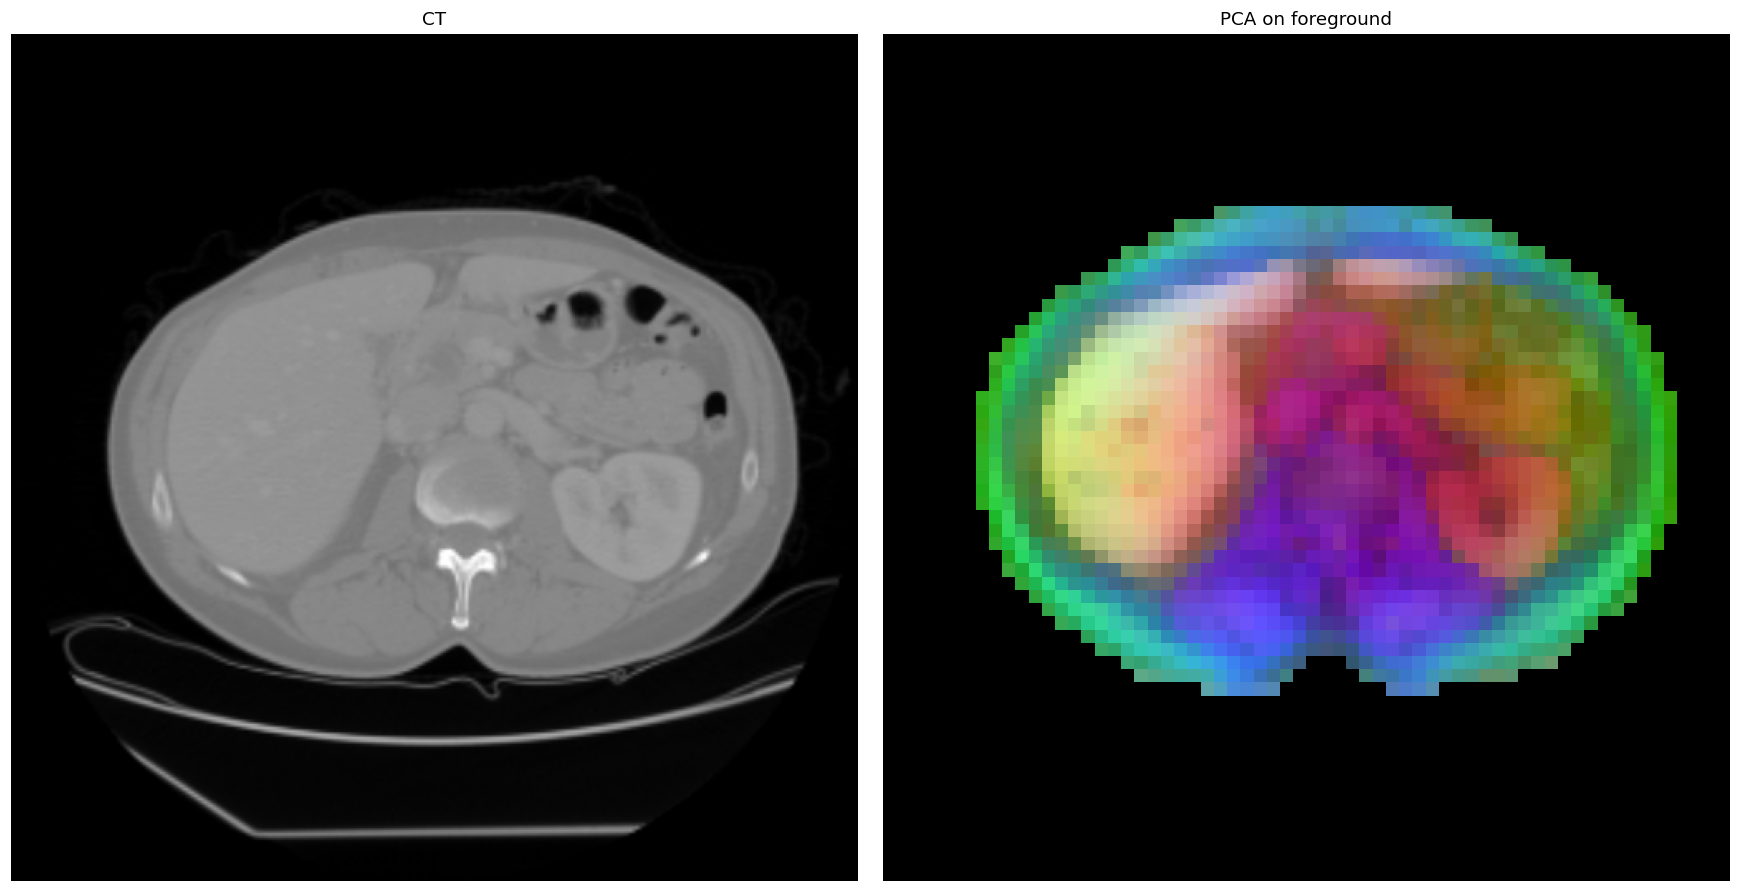

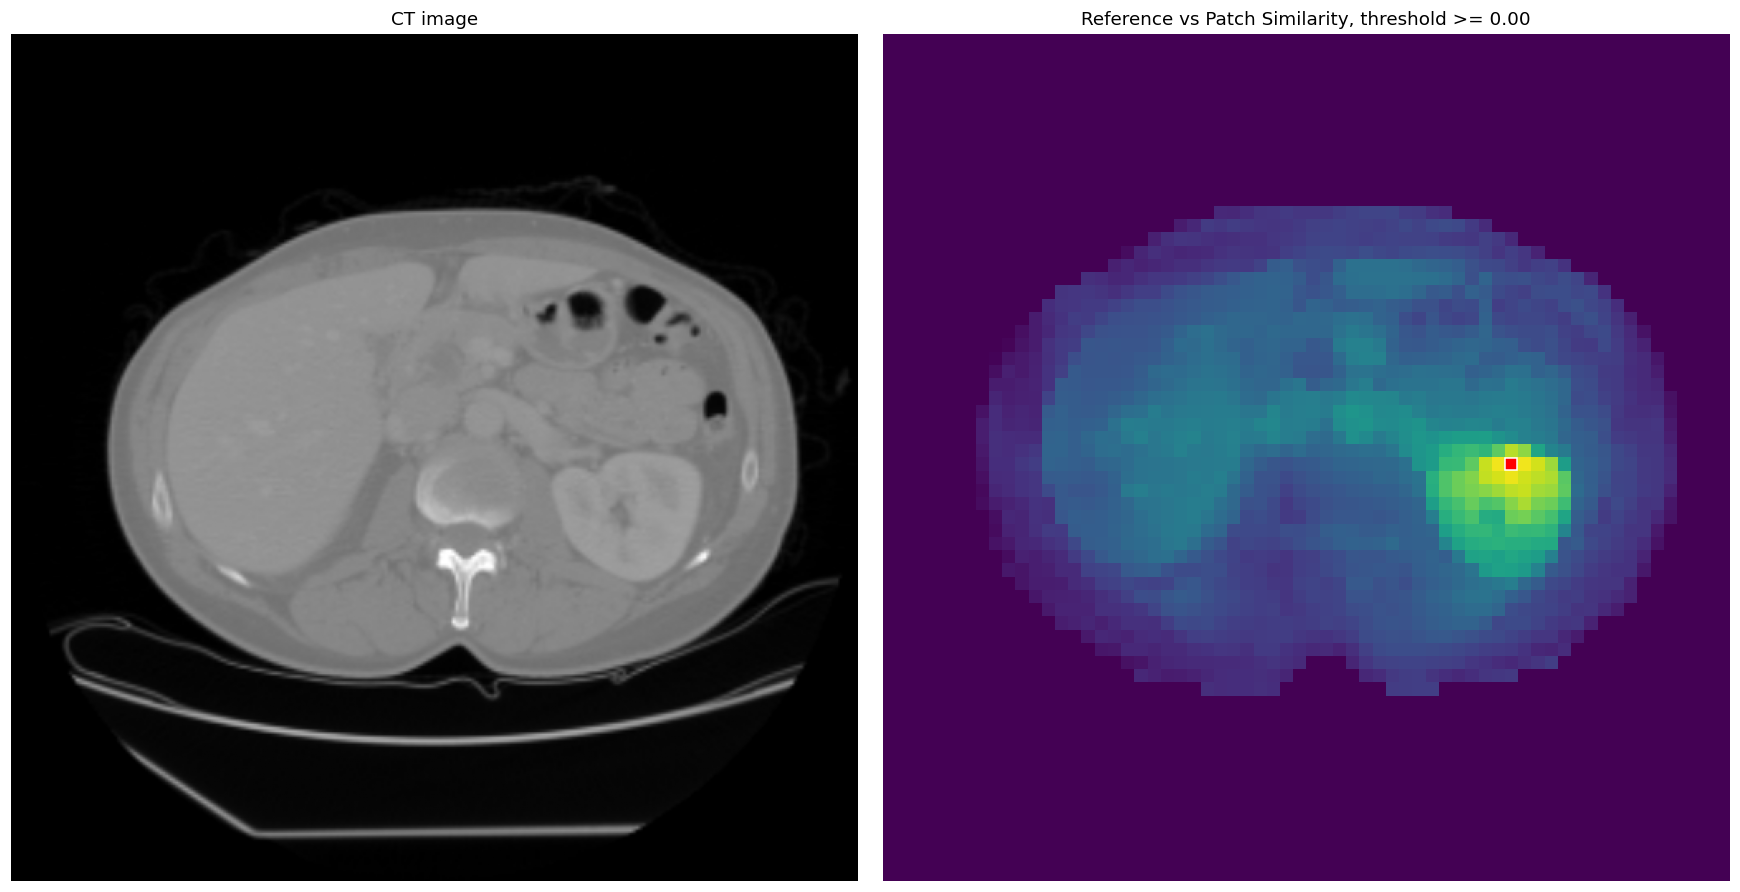

In [10]:
query_xy = (380, 260)
query_patch_index = click_xy_to_patch_index(query_xy, input_size=input_size, patch_size=model.patch_size)
print(f"Query xy={query_xy} -> patch index {query_patch_index}")

visualize_pca_masked(model_image, model, input_size)
visualize_ref_patch_masked(model_image, model, input_size, query_patch_index, use_alpha=False, threshold = 0.0)